<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/March2026/11MarchResnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dir = "/content/drive/MyDrive/ResearchData/DatasetTrainVsTest10march/Train"
val_dir = "/content/drive/MyDrive/ResearchData/DatasetTrainVsTest10march/Val"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)

['0', '1', '2', '3', '4', '5']


In [3]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
num_classes = 6   # change according to your dataset
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


In [4]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [9]:
import torch
import os

checkpoint_path = "/content/drive/MyDrive/Models/12march26Resnet18_checkpoint.pth"

best_val_acc = 0.0
epochs = 40

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ================= VALIDATION =================
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

    # ================= SAVE BEST MODEL =================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_acc
        }, checkpoint_path)

        print("✅ Best model saved")

Epoch [1/40] Train Loss: 0.6427 Train Acc: 77.68% | Val Loss: 0.9999 Val Acc: 57.30%
✅ Best model saved
Epoch [2/40] Train Loss: 0.6175 Train Acc: 78.75% | Val Loss: 1.0101 Val Acc: 57.30%
Epoch [3/40] Train Loss: 0.5961 Train Acc: 80.43% | Val Loss: 1.0201 Val Acc: 55.16%
Epoch [4/40] Train Loss: 0.6140 Train Acc: 77.06% | Val Loss: 1.0046 Val Acc: 56.23%
Epoch [5/40] Train Loss: 0.6038 Train Acc: 79.82% | Val Loss: 1.0062 Val Acc: 56.58%
Epoch [6/40] Train Loss: 0.5747 Train Acc: 80.43% | Val Loss: 1.0355 Val Acc: 55.16%
Epoch [7/40] Train Loss: 0.5403 Train Acc: 80.73% | Val Loss: 1.0102 Val Acc: 55.87%
Epoch [8/40] Train Loss: 0.5248 Train Acc: 83.33% | Val Loss: 1.0112 Val Acc: 56.58%
Epoch [9/40] Train Loss: 0.5505 Train Acc: 79.20% | Val Loss: 1.0660 Val Acc: 53.38%
Epoch [10/40] Train Loss: 0.5728 Train Acc: 77.06% | Val Loss: 1.1020 Val Acc: 54.09%
Epoch [11/40] Train Loss: 0.5047 Train Acc: 84.56% | Val Loss: 1.0151 Val Acc: 56.94%
Epoch [12/40] Train Loss: 0.5517 Train Acc: 

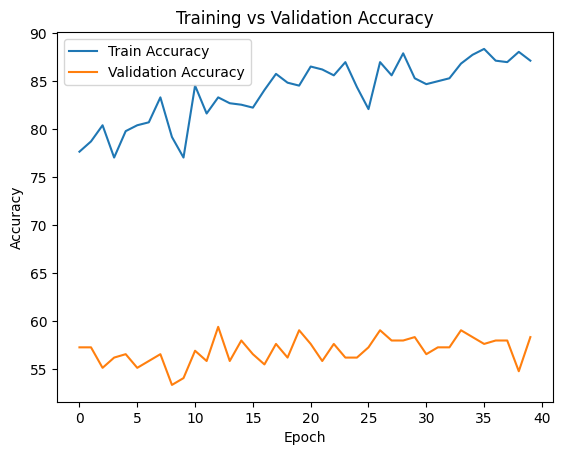

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

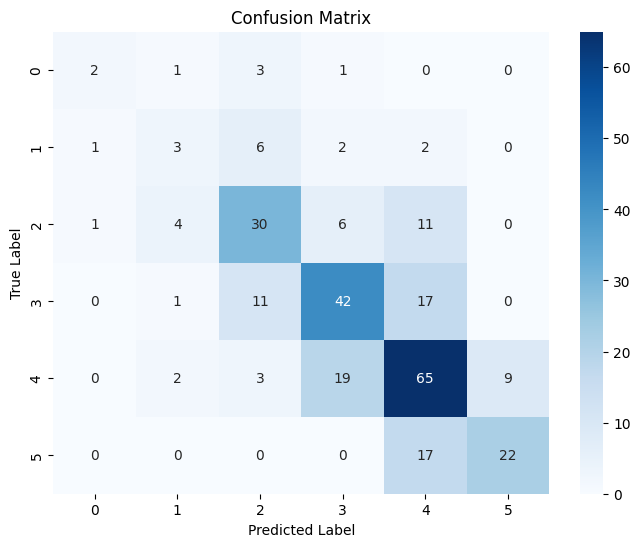

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = train_dataset.classes

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()